# Regression discontinuity: banking recovery

# Task 1

### Import Libraries


In [92]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


### Load the Dataset

In [93]:
# Load the dataset
df = pd.read_csv('C:/Users/PC/Documents/Internship_India/Internship1/Debt-Recovery-for-Bank-Collection-Using-Regression-Discontinuity/Bank Debt Data/bank_debt_data.csv')




### Data Exploration

In [94]:
# Basic information about the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1882 entries, 0 to 1881
Data columns (total 6 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        1882 non-null   int64  
 1   expected_recovery_amount  1882 non-null   int64  
 2   actual_recovery_amount    1882 non-null   float64
 3   recovery_strategy         1882 non-null   object 
 4   age                       1882 non-null   int64  
 5   sex                       1882 non-null   object 
dtypes: float64(1), int64(3), object(2)
memory usage: 88.3+ KB


In [95]:
# Summary statistics
df.describe()

,id,expected_recovery_amount,actual_recovery_amount,age
count,1882.000000,1882.000000,1882.000000,1882.000000
mean,1035.596174,2759.967588,4000.967837,39.650372
std,591.458429,2019.826565,4576.506350,15.453072
min,6.000000,194.000000,200.425000,18.000000
25%,534.250000,1261.250000,1045.190300,28.000000
50%,1029.500000,2062.000000,2115.446373,35.000000
75%,1551.750000,3569.500000,5417.237207,50.000000
max,2056.000000,9964.000000,34398.479710,84.000000


In [96]:
# Check for missing values
df.isnull().sum()

id                          0
expected_recovery_amount    0
actual_recovery_amount      0
recovery_strategy           0
age                         0
sex                         0
dtype: int64

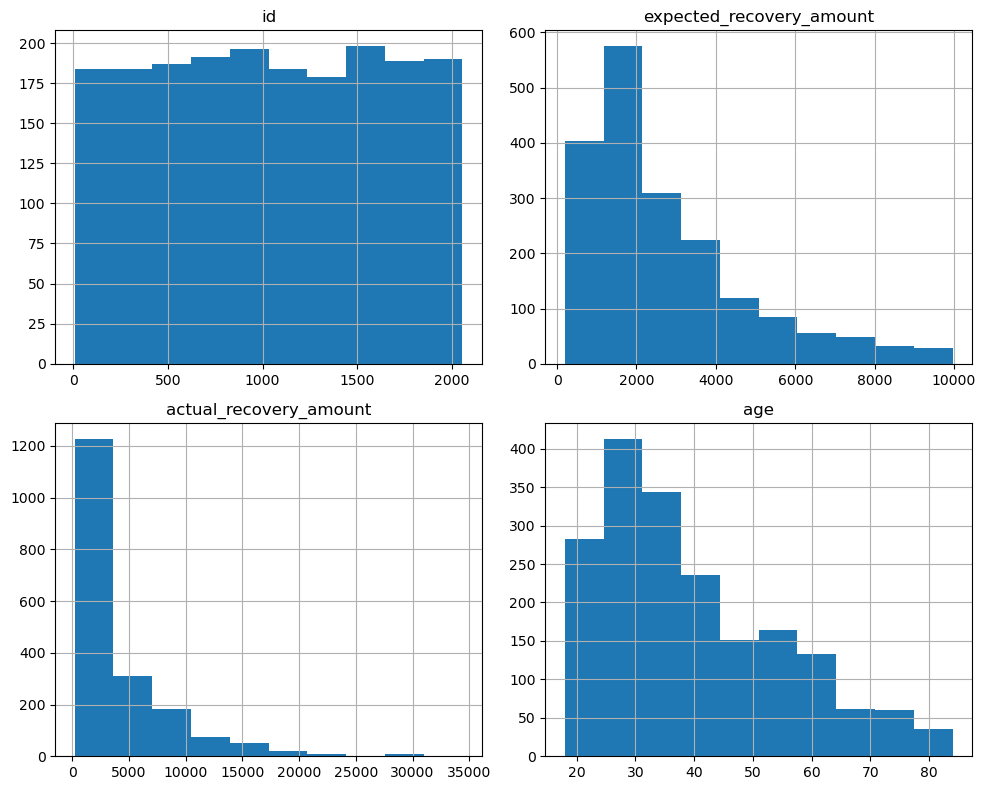

In [97]:
# Plot distribution of numerical features
df.hist(figsize=(10, 8))
plt.tight_layout()
plt.show()

### Data Cleaning

In [98]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Fill missing values with mean for numeric columns only
df[numeric_cols.columns] = numeric_cols.fillna(numeric_cols.mean())

# Verify if missing values were filled
print(df.isnull().sum())


id                          0
expected_recovery_amount    0
actual_recovery_amount      0
recovery_strategy           0
age                         0
sex                         0
dtype: int64


In [99]:
# Remove duplicates if any
df.drop_duplicates(inplace=True)

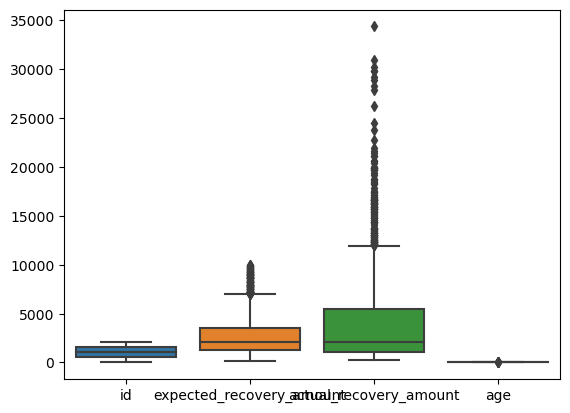

In [100]:
# Check for outliers using boxplot
sns.boxplot(data=df)
plt.show()

### Data Encoding

In [101]:
# Encoding categorical features
label_encoder = LabelEncoder()

In [102]:
# Apply encoding for categorical columns
for col in df.select_dtypes(include='object').columns:
    df[col] = label_encoder.fit_transform(df[col])


In [103]:
# Check if encoding is successful
df.head()

,id,expected_recovery_amount,actual_recovery_amount,recovery_strategy,age,sex
0,2030,194,263.540,0,19,1
1,1150,486,416.090,0,25,0
2,380,527,429.350,0,27,1
3,1838,536,296.990,0,25,1
4,1995,541,346.385,0,34,1


### Exploratory Data Analysis (EDA)

Visualize Age vs. Expected Recovery Amount

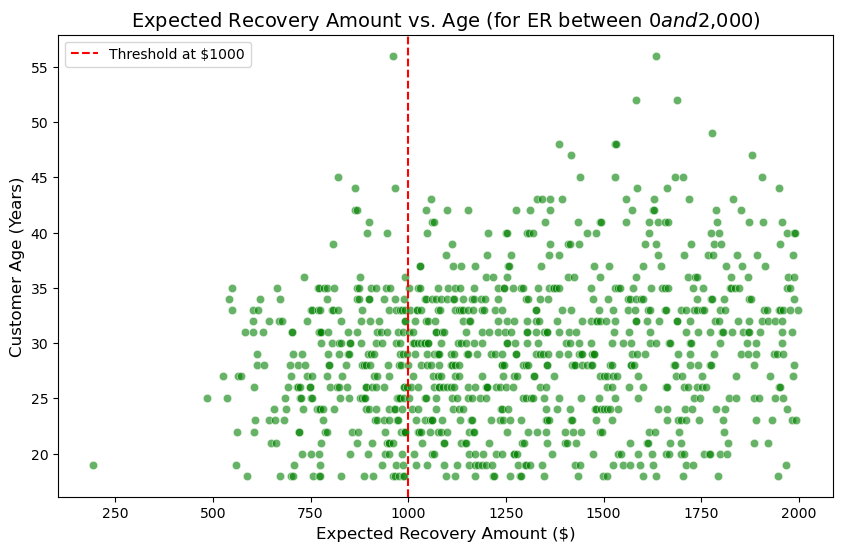

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for the Expected Recovery (ER) amount range between $0 and $2,000
filtered_data = df[(df['expected_recovery_amount'] > 0) & (df['expected_recovery_amount'] <= 2000)]

# Create a scatter plot of Expected Recovery Amount (ER) vs. Age
plt.figure(figsize=(10, 6))
sns.scatterplot(x='expected_recovery_amount', y='age', data=filtered_data, alpha=0.6, color="green")

# Add a vertical line at the $1,000 threshold to show the transition between Level 0 and Level 1
plt.axvline(x=1000, color='red', linestyle='--', label='Threshold at $1000')

# Add title and labels
plt.title('Expected Recovery Amount vs. Age (for ER between $0 and $2,000)', fontsize=14)
plt.xlabel('Expected Recovery Amount ($)', fontsize=12)
plt.ylabel('Customer Age (Years)', fontsize=12)
plt.legend()

# Show plot
plt.show()


### Statistical Test: Age vs. Expected Recovery Amount

In [105]:
import scipy.stats as stats

# Filter data for customers with Expected Recovery Amount (ER) between $900 and $1,100
filtered_data_age_test = df[(df['expected_recovery_amount'] > 900) & (df['expected_recovery_amount'] < 1100)]

# Separate the data into two groups: below and above the $1,000 threshold
group_below_threshold = filtered_data_age_test[filtered_data_age_test['expected_recovery_amount'] <= 1000]
group_above_threshold = filtered_data_age_test[filtered_data_age_test['expected_recovery_amount'] > 1000]

# Extract the 'age' column for both groups
age_below_threshold = group_below_threshold['age']
age_above_threshold = group_above_threshold['age']

# Perform the Mann-Whitney U test (non-parametric test)
stat, p_value = stats.mannwhitneyu(age_below_threshold, age_above_threshold, alternative='two-sided')

# Results
print(f"Test statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in age across the threshold.")
else:
    print("Fail to reject the null hypothesis: No significant difference in age across the threshold.")


Test statistic: 3338.5000
P-value: 0.0438
Reject the null hypothesis: There is a significant difference in age across the threshold.


### Statistical Test: Gender vs. Expected Recovery Amount

In [106]:
from statsmodels.stats.proportion import proportions_ztest

# Filter data for customers with Expected Recovery Amount (ER) between $900 and $1,100
filtered_data_gender_test = df[(df['expected_recovery_amount'] > 900) & (df['expected_recovery_amount'] < 1100)]

# Separate the data into two groups: below and above the $1,000 threshold
group_below_threshold = filtered_data_gender_test[filtered_data_gender_test['expected_recovery_amount'] <= 1000]
group_above_threshold = filtered_data_gender_test[filtered_data_gender_test['expected_recovery_amount'] > 1000]

# Calculate the number of male customers in each group
n_below = len(group_below_threshold)
n_above = len(group_above_threshold)

n_male_below = (group_below_threshold['sex'] == 'male').sum()
n_male_above = (group_above_threshold['sex'] == 'male').sum()

# Perform a proportion z-test
count = [n_male_below, n_male_above]
nobs = [n_below, n_above]
stat, p_value = proportions_ztest(count, nobs)

# Results
print(f"Z-test statistic: {stat:.4f}")
print(f"P-value: {p_value:.4f}")

# Interpretation
if p_value < 0.05:
    print("Reject the null hypothesis: There is a significant difference in the proportion of male customers across the threshold.")
else:
    print("Fail to reject the null hypothesis: No significant difference in the proportion of male customers across the threshold.")


Z-test statistic: nan
P-value: nan
Fail to reject the null hypothesis: No significant difference in the proportion of male customers across the threshold.


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\stats\weightstats.py:792: RuntimeWarning: invalid value encountered in scalar divide
  zstat = value / std


### Exploratory Graphical Analysis: Recovery Amount

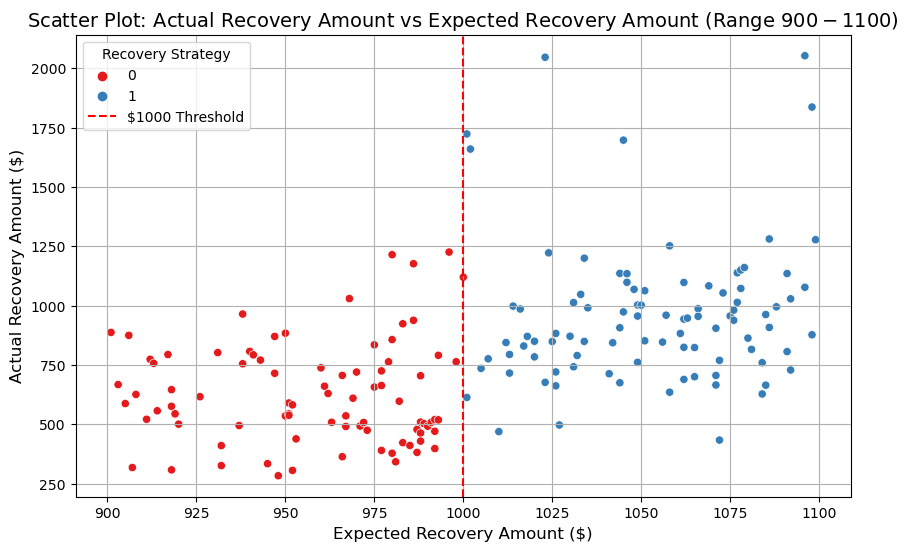

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data for customers with Expected Recovery Amount (ER) between $900 and $1,100
filtered_data_recovery = df[(df['expected_recovery_amount'] > 900) & (df['expected_recovery_amount'] < 1100)]

# Create a scatter plot of Actual Recovery Amount vs. Expected Recovery Amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='expected_recovery_amount', y='actual_recovery_amount', data=filtered_data_recovery, hue='recovery_strategy', palette='Set1')

# Add a vertical line at the $1,000 threshold to indicate the transition between Level 0 and Level 1
plt.axvline(x=1000, color='red', linestyle='--', label='$1000 Threshold')

# Add titles and labels
plt.title('Scatter Plot: Actual Recovery Amount vs Expected Recovery Amount (Range $900 - $1100)', fontsize=14)
plt.xlabel('Expected Recovery Amount ($)', fontsize=12)
plt.ylabel('Actual Recovery Amount ($)', fontsize=12)
plt.legend(title='Recovery Strategy')
plt.grid(True)

# Show the plot
plt.show()


### Regression Modeling: No Threshold

In [108]:
import statsmodels.formula.api as smf

# Build a simple linear regression model: actual recovery amount as a function of expected recovery amount
model_no_threshold = smf.ols('actual_recovery_amount ~ expected_recovery_amount', data=df).fit()

# Print the summary of the regression model
print(model_no_threshold.summary())



                              OLS Regression Results                              
Dep. Variable:     actual_recovery_amount   R-squared:                       0.817
Model:                                OLS   Adj. R-squared:                  0.817
Method:                     Least Squares   F-statistic:                     8378.
Date:                    Tue, 08 Oct 2024   Prob (F-statistic):               0.00
Time:                            19:36:45   Log-Likelihood:                -16936.
No. Observations:                    1882   AIC:                         3.388e+04
Df Residuals:                        1880   BIC:                         3.389e+04
Df Model:                               1                                         
Covariance Type:                nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

### Regression Modeling: With Threshold

In [79]:
import statsmodels.formula.api as smf

# Create a new column for the threshold indicator (1 if ER > 1000, 0 if ER <= 1000)
df['above_threshold'] = (df['expected_recovery_amount'] > 1000).astype(int)

# Build a regression model with the threshold indicator
model_with_threshold = smf.ols('actual_recovery_amount ~ expected_recovery_amount * above_threshold', data=df).fit()

# Print the summary of the regression model
print(model_with_threshold.summary())


                              OLS Regression Results                              
Dep. Variable:     actual_recovery_amount   R-squared:                       0.819
Model:                                OLS   Adj. R-squared:                  0.818
Method:                     Least Squares   F-statistic:                     4242.
Date:                    Tue, 08 Oct 2024   Prob (F-statistic):               0.00
Time:                            00:31:32   Log-Likelihood:                -16926.
No. Observations:                    1882   AIC:                         3.386e+04
Df Residuals:                        1879   BIC:                         3.387e+04
Df Model:                               2                                         
Covariance Type:                nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

 ### Robustness Check (Adjusting Windows)

In [89]:
import statsmodels.formula.api as smf

# Filter the data for the adjusted analysis window (e.g., between $950 and $1050)
df_window = df[(df['expected_recovery_amount'] >= 950) & (df['expected_recovery_amount'] <= 1050)]

# Create a threshold indicator for the adjusted window
df_window['above_threshold'] = (df_window['expected_recovery_amount'] > 1000).astype(int)

# Build the regression model for the adjusted window
model_window = smf.ols('actual_recovery_amount ~ expected_recovery_amount * above_threshold', data=df_window).fit()

# Print the summary of the regression model for the adjusted window
print(model_window.summary())


                              OLS Regression Results                              
Dep. Variable:     actual_recovery_amount   R-squared:                       0.271
Model:                                OLS   Adj. R-squared:                  0.248
Method:                     Least Squares   F-statistic:                     11.91
Date:                    Tue, 08 Oct 2024   Prob (F-statistic):           1.07e-06
Time:                            19:36:29   Log-Likelihood:                -700.54
No. Observations:                     100   AIC:                             1409.
Df Residuals:                          96   BIC:                             1420.
Df Model:                               3                                         
Covariance Type:                nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

C:\Users\PC\AppData\Local\Temp\ipykernel_19808\3375723948.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_window['above_threshold'] = (df_window['expected_recovery_amount'] > 1000).astype(int)


In [90]:
df_window = df[(df['expected_recovery_amount'] >= 975) & (df['expected_recovery_amount'] <= 1025)]


In [91]:
df_window = df[(df['expected_recovery_amount'] >= 900) & (df['expected_recovery_amount'] <= 1100)]
